In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

import os

# hide warnings
import warnings
warnings.filterwarnings('ignore')

In [66]:
!pip install -U gdown

In [67]:
!gdown  1Zim4ODFec7nQqx5W_l8XzwzC_IB-3rmq

Downloading...
From: https://drive.google.com/uc?id=1Zim4ODFec7nQqx5W_l8XzwzC_IB-3rmq
To: /content/CarPrice_Assignment.csv
100% 26.7k/26.7k [00:00<00:00, 42.9MB/s]


In [68]:
# reading the dataset
cars = pd.read_csv("CarPrice_Assignment.csv")

In [69]:
print(cars.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [70]:
# head
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [71]:
cars.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [72]:
cars['symboling'].astype('category').value_counts()

# symboling: -2 (least risky) to +3 most risky
# Most cars are 0,1,2

,count
symboling,
0,67
1,54
2,32
3,27
-1,22
-2,3


In [73]:
# aspiration: An (internal combustion) engine property showing
# whether the oxygen intake is through standard (atmospheric pressure)
# or through turbocharging (pressurised oxygen intake)

cars['aspiration'].astype('category').value_counts()

,count
aspiration,
std,168
turbo,37


In [74]:
# drivewheel: frontwheel, rarewheel or four-wheel drive
cars['drivewheel'].astype('category').value_counts()

,count
drivewheel,
fwd,120
rwd,76
4wd,9


## Basic plotting

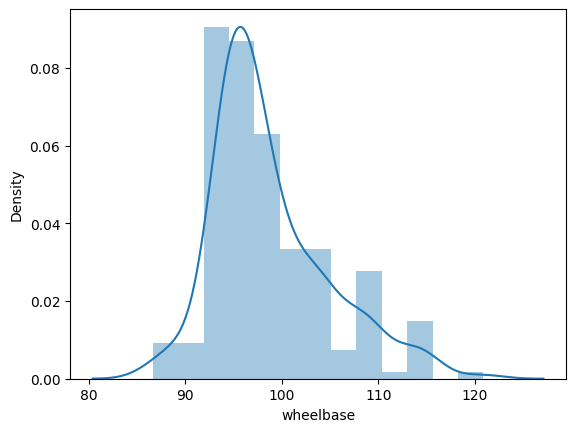

In [75]:
sns.distplot(cars['wheelbase'])
plt.show()

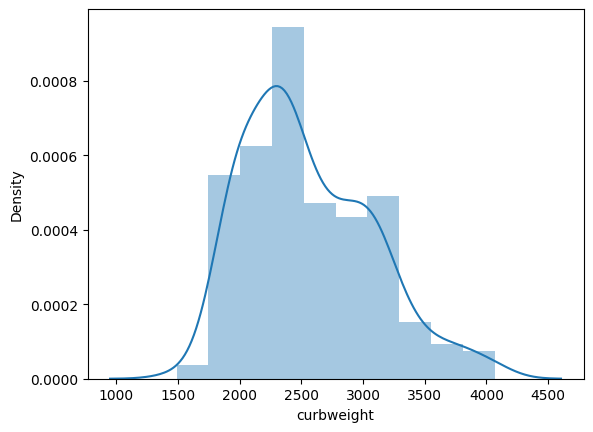

In [76]:
# curbweight: weight of car without occupants or baggage
sns.distplot(cars['curbweight'])
plt.show()

In [77]:
cars.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

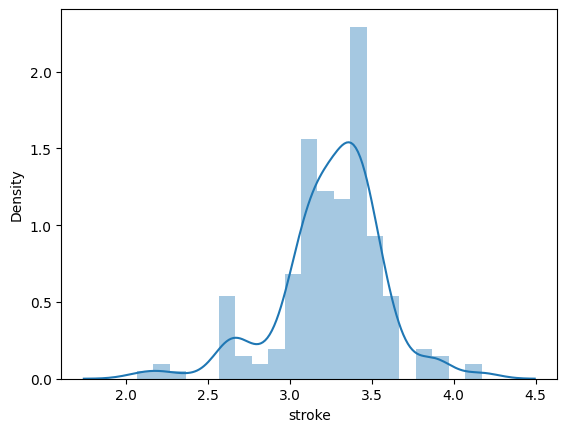

In [78]:
# stroke: volume of the engine (the distance traveled by the
# piston in each cycle)
sns.distplot(cars['stroke'])
plt.show()

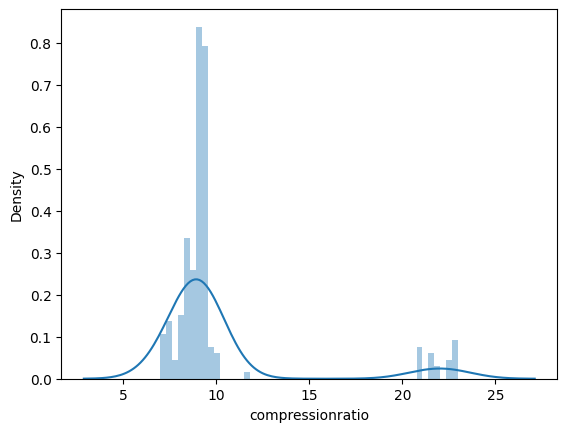

In [79]:
# compression ration: ratio of volume of compression chamber
# at largest capacity to least capacity
sns.distplot(cars['compressionratio'])
plt.show()

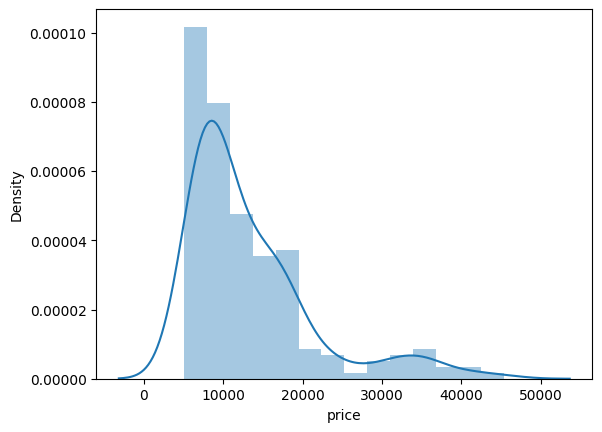

In [80]:
# target variable: price of car
sns.distplot(cars['price'])
plt.show()

#### Data Exploration

To perform linear regression, the (numeric) target variable should be linearly related to *at least one another numeric variable*. Let's see whether that's true in this case.


We'll first subset the list of all (independent) numeric variables, and then make a **pairwise plot**.

In [81]:
cars.dtypes

,0
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64


In [82]:
cars_numeric = cars.select_dtypes(include=['float64', 'int64'])
cars_numeric.head()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0


In [83]:
# dropping symboling and car_ID
cars_numeric = cars_numeric.drop(['symboling'], axis=1)
cars_numeric.head()

,car_ID,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0


In [84]:
# paiwise scatter plot
plt.figure(figsize=(20, 10))
sns.pairplot(cars_numeric)
plt.show()

<Figure size 2000x1000 with 0 Axes>

KeyboardInterrupt: 

In [85]:
# correlation matrix

cor = cars_numeric.corr()
cor

,car_ID,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
wheelbase,0.129729,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443
compressionratio,0.150276,0.249786,0.158414,0.181129,0.261214,0.151362,0.028971,0.005197,0.186110,1.000000,-0.204326,-0.435741,0.324701,0.265201,0.067984


<Axes: >

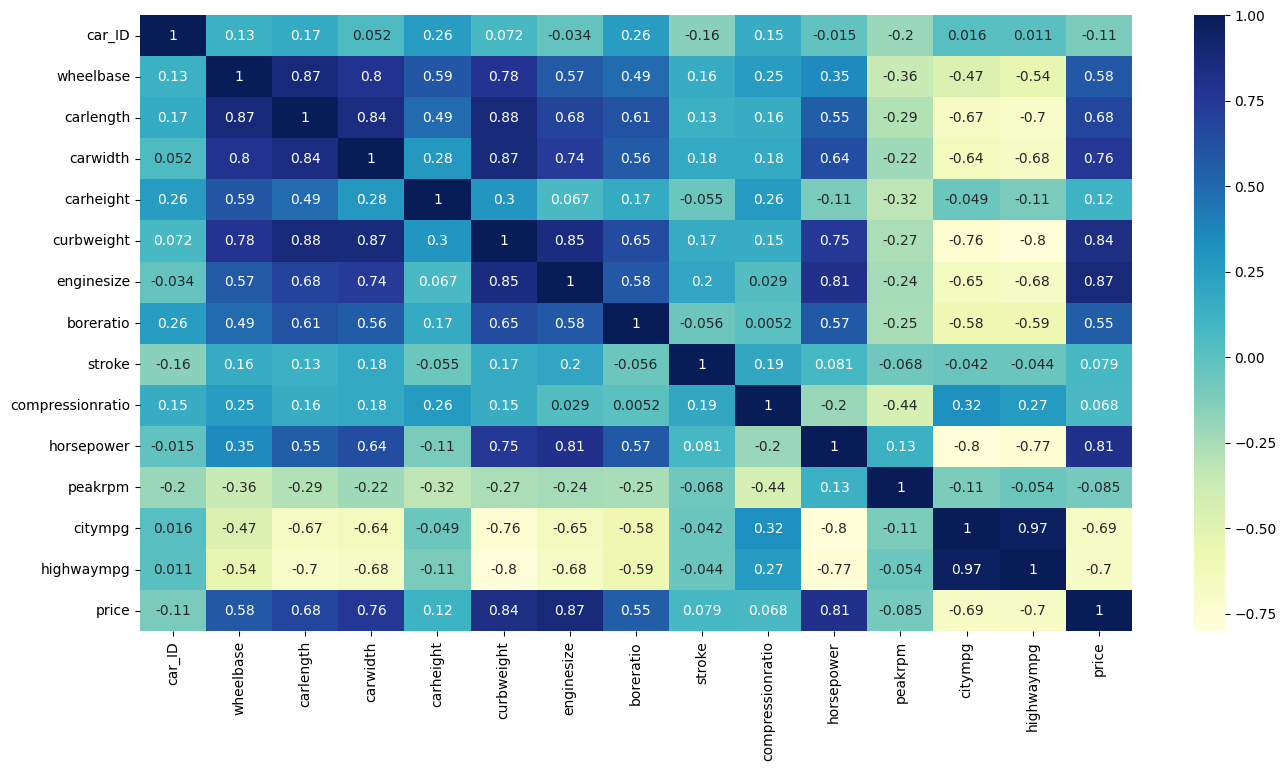

In [86]:
plt.figure(figsize=(16,8))

sns.heatmap(cor, cmap = 'YlGnBu', annot = True)

The heatmap shows some useful insights:

Correlation of price with independent variables:
- Price is highly (positively) correlated with wheelbase, carlength, carwidth, curbweight, enginesize, horsepower (notice how all of these variables represent the size/weight/engine power of the car)

- Price is negatively correlated to ```citympg``` and ```highwaympg``` (-0.70 approximately). This suggest that cars having high mileage may fall in the 'economy' cars category, and are priced lower (think Maruti Alto/Swift type of cars, which are designed to be affordable by the middle class, who value mileage more than horsepower/size of car etc.)

Correlation among independent variables:
- Many independent variables are highly correlated (look at the top-left part of matrix): wheelbase, carlength, curbweight, enginesize etc. are all measures of 'size/weight', and are positively correlated


Thus, while building the model, we'll have to pay attention to multicollinearity (especially linear models, such as linear and logistic regression, suffer more from multicollinearity).

In [87]:
cars.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [88]:
# converting symboling to categorical
cars['symboling'] = cars['symboling'].astype('object')
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    object 
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

## Data cleaning

In [89]:
cars

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [90]:
# CarName: first few entries
cars['CarName'][:30]

,CarName
0,alfa-romero giulia
1,alfa-romero stelvio
2,alfa-romero Quadrifoglio
3,audi 100 ls
4,audi 100ls
5,audi fox
6,audi 100ls
7,audi 5000
8,audi 4000
9,audi 5000s (diesel)


In [91]:
carnames = cars['CarName'].apply(lambda x: x.split(" ")[0])

In [92]:
carnames[:30]

,CarName
0,alfa-romero
1,alfa-romero
2,alfa-romero
3,audi
4,audi
5,audi
6,audi
7,audi
8,audi
9,audi


In [93]:
# Method 2: Use regular expressions
import re

# regex: any alphanumeric sequence before a space, may contain a hyphen
p = re.compile(r'\w+-?\w+')

carnames = cars['CarName'].apply(lambda x: re.findall(p, x)[0])
print(carnames)

0      alfa-romero
1      alfa-romero
2      alfa-romero
3             audi
4             audi
          ...     
200          volvo
201          volvo
202          volvo
203          volvo
204          volvo
Name: CarName, Length: 205, dtype: object


In [94]:
cars['car_company'] = cars['CarName'].apply(lambda x: re.findall(p, x)[0])

In [95]:
cars['car_company'].astype('category').value_counts()

,count
car_company,
toyota,31
nissan,17
mazda,15
honda,13
mitsubishi,13
subaru,12
volvo,11
peugeot,11
dodge,9


In [96]:
# replacing misspelled car_company names

# volkswagen
cars.loc[(cars['car_company'] == "vw") |
         (cars['car_company'] == "vokswagen")
         , 'car_company'] = 'volkswagen'

In [97]:
# replacing misspelled car_company names

# volkswagen
cars.loc[(cars['car_company'] == "vw") |
         (cars['car_company'] == "vokswagen")
         , 'car_company'] = 'volkswagen'

# porsche
cars.loc[cars['car_company'] == "porcshce", 'car_company'] = 'porsche'

# toyota
cars.loc[cars['car_company'] == "toyouta", 'car_company'] = 'toyota'

# nissan
cars.loc[cars['car_company'] == "Nissan", 'car_company'] = 'nissan'

# mazda
cars.loc[cars['car_company'] == "maxda", 'car_company'] = 'mazda'

In [98]:
cars['car_company'].astype('category').value_counts()

,count
car_company,
toyota,32
nissan,18
mazda,17
mitsubishi,13
honda,13
subaru,12
volkswagen,12
peugeot,11
volvo,11


In [99]:
# drop carname variable
cars = cars.drop('CarName', axis=1)

In [100]:
cars.columns

Index(['car_ID', 'symboling', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price',
       'car_company'],
      dtype='object')

In [101]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.000000,59.322565,1.00,52.00,103.00,154.00,205.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17
compressionratio,205.0,10.142537,3.972040,7.00,8.60,9.00,9.40,23.00


In [102]:
cars.head()

,car_ID,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,1,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,gas,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,gas,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,gas,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


## Encoding and Scaling

## Deliberately show you some new things - but that does not mean that you have to use it. My goal is to make you aware that these functions exist, so that when you raed someone elses code, you understand what they want to do

## Column Transformers and Pipleines

### Column Transformers
As the name itself says, Column Transformers help in performing any of the similar type of task like either Encoding or Scaling or Imputation, using different strategies at the same time, on different set of columns.

This benefits because all these transformations are done parallelly on the set of columns provided to the transformers.

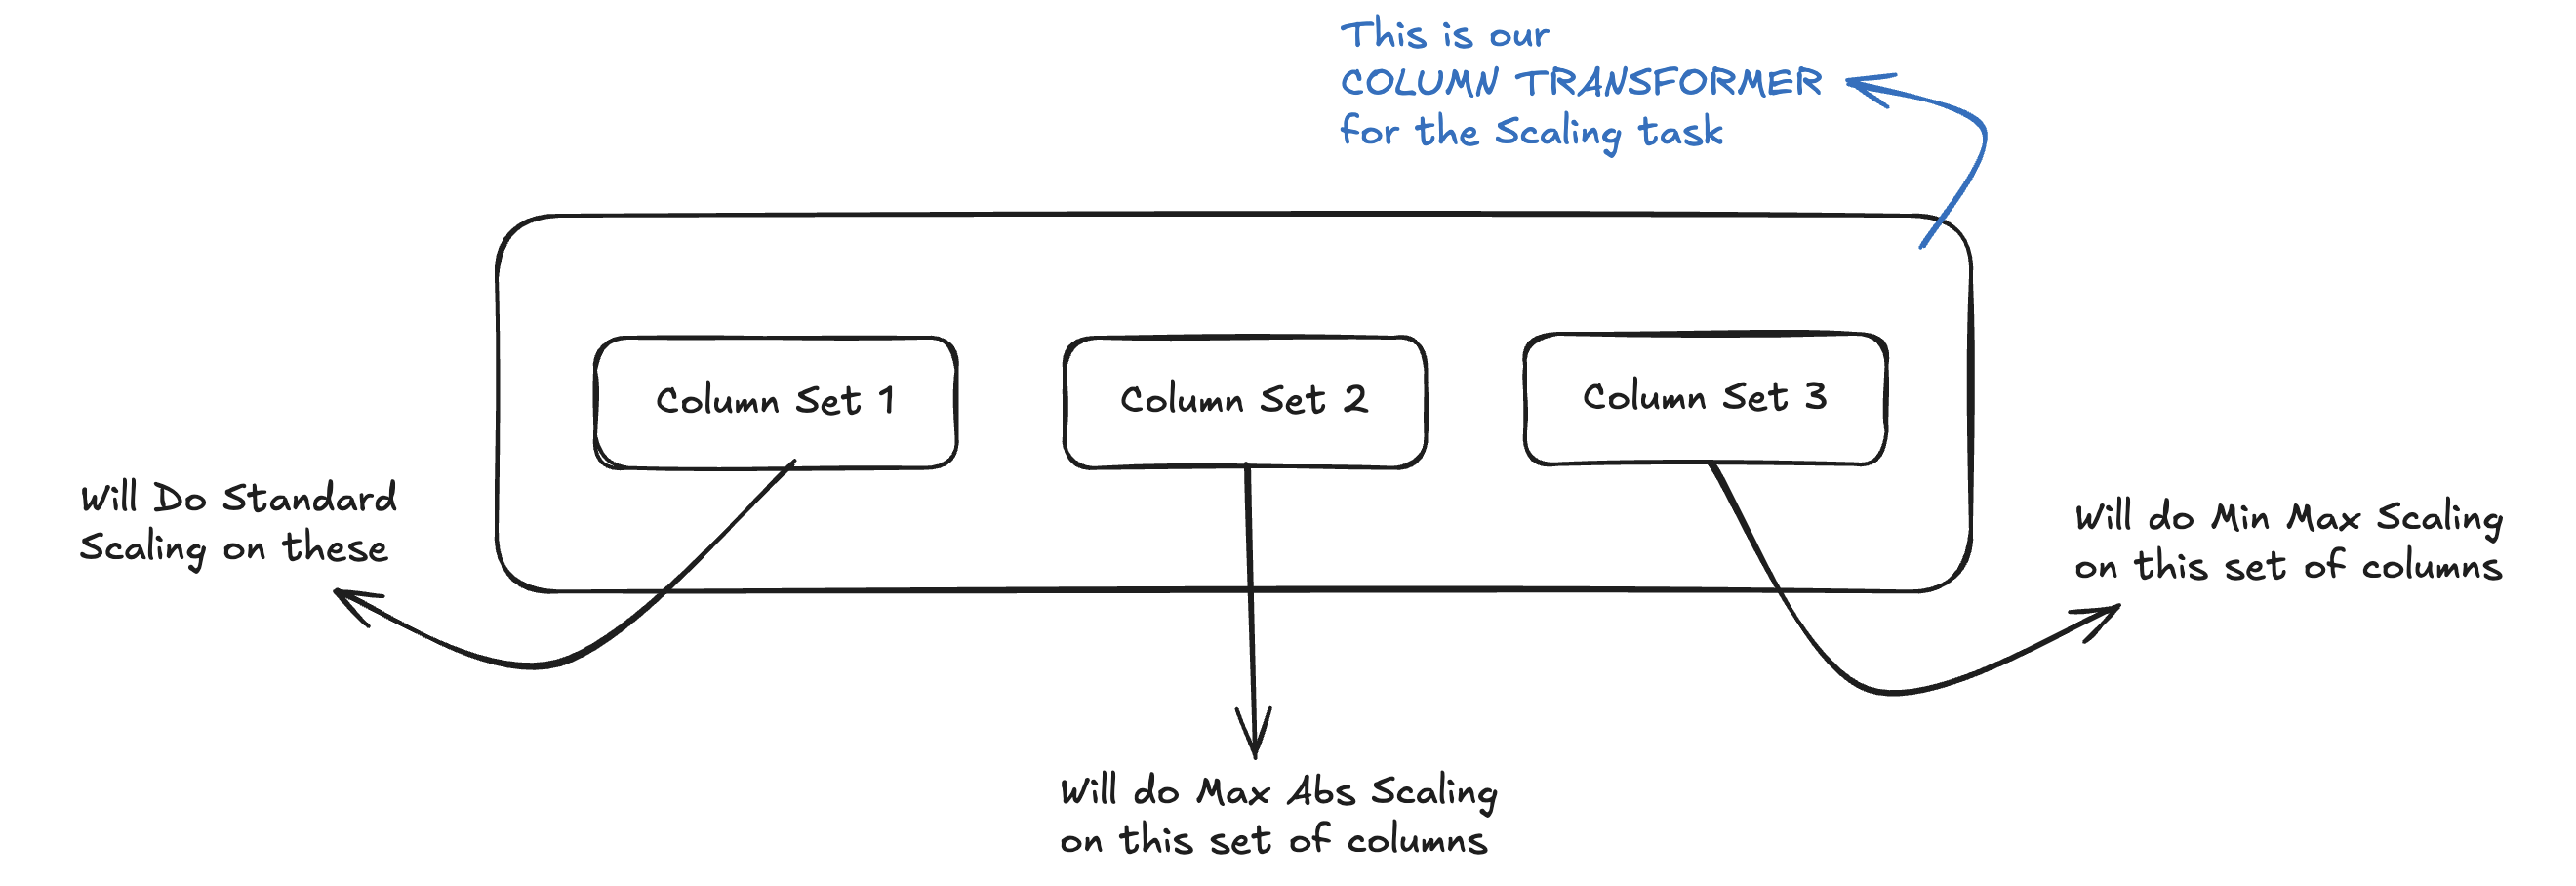

In [103]:
# Extracting out the numerical columns from the cleaned CARS24 dataset
num_cols = cars.select_dtypes(include='number').columns
num_cols

Index(['car_ID', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [104]:
# Extracting out the categorical columns from the cleaned CARS24 dataset
cat_cols = cars.select_dtypes(include='object').columns
cat_cols

Index(['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem', 'car_company'],
      dtype='object')

Now lets take up the task of performing **Standard Scaling**, **Min Max Scaling** and **Max Absolute Scaling** on 5-5 columns each of the numerical columns.

Lets randomly select the set of columns for this task:
```
1. Columns for Standard Scaling = ['car_ID','carwidth','enginesize','compressionratio','citympg']
2. Columns for Min Max Scaling = ['wheelbase','carheight','boreratio','horsepower','highwaympg']
3. Columns for Max Absolute Scaling = ['carlength','curbweight','stroke','peakrpm','price']
```

In [105]:
# necessary imports
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

In [106]:
# defining the transformer
scaling_transformer = ColumnTransformer(transformers =
[
    ('Standard Scaler', StandardScaler(), ['car_ID','carwidth','enginesize','compressionratio','citympg']),
    ('Min-Max Scaler', MinMaxScaler(), ['wheelbase','carheight','boreratio','horsepower','highwaympg']),
    ('Max Absolute Scaling', MaxAbsScaler(), ['carlength','curbweight','stroke','peakrpm','price'])
],
                                        remainder='drop').set_output(transform='pandas')

scaling_transformer

ColumnTransformer(transformers=[('Standard Scaler', StandardScaler(),
                                 ['car_ID', 'carwidth', 'enginesize',
                                  'compressionratio', 'citympg']),
                                ('Min-Max Scaler', MinMaxScaler(),
                                 ['wheelbase', 'carheight', 'boreratio',
                                  'horsepower', 'highwaympg']),
                                ('Max Absolute Scaling', MaxAbsScaler(),
                                 ['carlength', 'curbweight', 'stroke',
                                  'peakrpm', 'price'])])

In [107]:
# fitting and transforming the cars dataset as per the created transformer.
scaled_num_cols = scaling_transformer.fit_transform(cars)
scaled_num_cols

,Standard Scaler__car_ID,Standard Scaler__carwidth,Standard Scaler__enginesize,Standard Scaler__compressionratio,Standard Scaler__citympg,Min-Max Scaler__wheelbase,Min-Max Scaler__carheight,Min-Max Scaler__boreratio,Min-Max Scaler__horsepower,Min-Max Scaler__highwaympg,Max Absolute Scaling__carlength,Max Absolute Scaling__curbweight,Max Absolute Scaling__stroke,Max Absolute Scaling__peakrpm,Max Absolute Scaling__price
0,-1.723622,-0.844782,0.074449,-0.288349,-0.646553,0.058309,0.083333,0.664286,0.262500,0.289474,0.811148,0.626660,0.642686,0.757576,0.297247
1,-1.706724,-0.844782,0.074449,-0.288349,-0.646553,0.058309,0.083333,0.664286,0.262500,0.289474,0.811148,0.626660,0.642686,0.757576,0.363436
2,-1.689826,-0.190566,0.604046,-0.288349,-0.953012,0.230321,0.383333,0.100000,0.441667,0.263158,0.822681,0.694294,0.832134,0.757576,0.363436
3,-1.672928,0.136542,-0.431076,-0.035973,-0.186865,0.384840,0.541667,0.464286,0.225000,0.368421,0.848630,0.574766,0.815348,0.833333,0.307269
4,-1.656029,0.230001,0.218885,-0.540725,-1.106241,0.373178,0.541667,0.464286,0.279167,0.157895,0.848630,0.694540,0.815348,0.833333,0.384361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.656029,1.398245,0.339248,-0.162161,-0.340094,0.655977,0.641667,0.885714,0.275000,0.315789,0.907256,0.726021,0.755396,0.818182,0.371035
201,1.672928,1.351515,0.339248,-0.364062,-0.953012,0.655977,0.641667,0.885714,0.466667,0.236842,0.907256,0.749877,0.755396,0.803030,0.419493
202,1.689826,1.398245,1.109571,-0.338824,-1.106241,0.655977,0.641667,0.742857,0.358333,0.184211,0.907256,0.740777,0.688249,0.833333,0.473238
203,1.706724,1.398245,0.435538,3.244916,0.119594,0.655977,0.641667,0.335714,0.241667,0.289474,0.907256,0.791195,0.815348,0.727273,0.494934


In [108]:
## 10 : 18 pm

In [109]:
# Necessary imports for the Encoding part
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [110]:
# categories list for the Ordinal encoder part
OE_categories_list = [
    [-2,-1,3,2,1,0],
    ['two','three','four','five','six','eight','twelve']
]


# defining the transformer
encoding_transformer = ColumnTransformer(transformers =
 [
     ('Ordinal encoder', OrdinalEncoder(categories=OE_categories_list), ['symboling','cylindernumber']),
     ('One Hot Encoder', OneHotEncoder(sparse_output=False), ['symboling','fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','enginetype','cylindernumber','fuelsystem','car_company'])
 ],
                                         remainder='drop').set_output(transform='pandas')

encoding_transformer

ColumnTransformer(transformers=[('Ordinal encoder',
                                 OrdinalEncoder(categories=[[-2, -1, 3, 2, 1,
                                                             0],
                                                            ['two', 'three',
                                                             'four', 'five',
                                                             'six', 'eight',
                                                             'twelve']]),
                                 ['symboling', 'cylindernumber']),
                                ('One Hot Encoder',
                                 OneHotEncoder(sparse_output=False),
                                 ['symboling', 'fueltype', 'aspiration',
                                  'doornumber', 'carbody', 'drivewheel',
                                  'enginelocation', 'enginetype',
                                  'cylindernumber', 'fuelsystem',
                                  'car_company'])])

In [111]:
# fitting and transforming the cars dataset as per the created transformer.
encoded_cat_cols = encoding_transformer.fit_transform(cars)
encoded_cat_cols

,Ordinal encoder__symboling,Ordinal encoder__cylindernumber,One Hot Encoder__symboling_-2,One Hot Encoder__symboling_-1,One Hot Encoder__symboling_0,One Hot Encoder__symboling_1,One Hot Encoder__symboling_2,One Hot Encoder__symboling_3,One Hot Encoder__fueltype_diesel,One Hot Encoder__fueltype_gas,...,One Hot Encoder__car_company_nissan,One Hot Encoder__car_company_peugeot,One Hot Encoder__car_company_plymouth,One Hot Encoder__car_company_porsche,One Hot Encoder__car_company_renault,One Hot Encoder__car_company_saab,One Hot Encoder__car_company_subaru,One Hot Encoder__car_company_toyota,One Hot Encoder__car_company_volkswagen,One Hot Encoder__car_company_volvo
0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
201,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
202,1.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
203,1.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Now both these tasks can be simultaneously performed directly on the entire dataset of CARS24 at once.

That is, just pass the cleaned data as input and get the pre-processed data as the final output.

This is done with the help of `Pipeline` in sklearn.

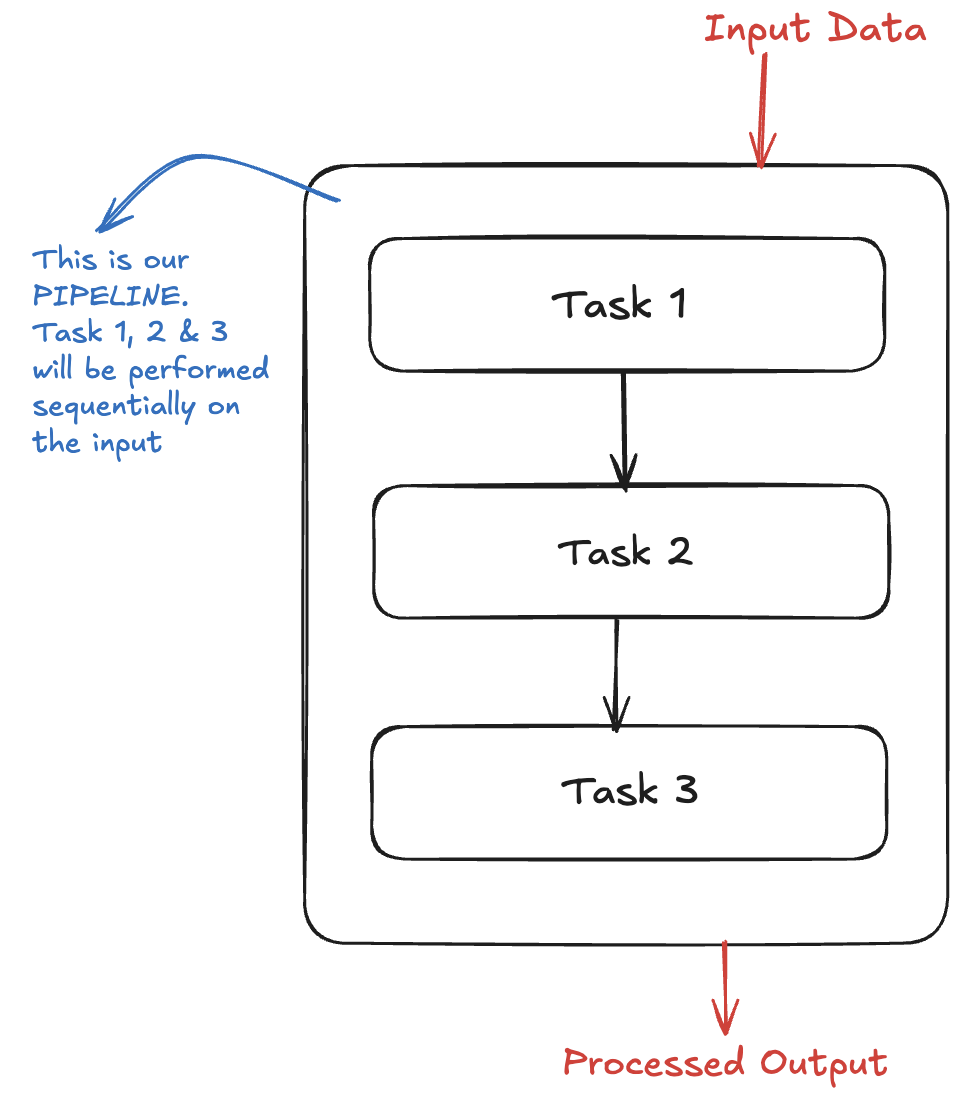

In [112]:
# Tuning the scaling transformer accordingly for the pipeline
scaling_tf = ColumnTransformer(transformers =
[
    ('Standard Scaler', StandardScaler(), ['car_ID','carwidth','enginesize','compressionratio','citympg']),
    ('Min-Max Scaler', MinMaxScaler(), ['wheelbase','carheight','boreratio','horsepower','highwaympg']),
    ('Max Absolute Scaling', MaxAbsScaler(), ['carlength','curbweight','stroke','peakrpm','price'])
],
                                        remainder='passthrough',verbose_feature_names_out=False).set_output(transform='pandas')

scaling_tf

ColumnTransformer(remainder='passthrough',
                  transformers=[('Standard Scaler', StandardScaler(),
                                 ['car_ID', 'carwidth', 'enginesize',
                                  'compressionratio', 'citympg']),
                                ('Min-Max Scaler', MinMaxScaler(),
                                 ['wheelbase', 'carheight', 'boreratio',
                                  'horsepower', 'highwaympg']),
                                ('Max Absolute Scaling', MaxAbsScaler(),
                                 ['carlength', 'curbweight', 'stroke',
                                  'peakrpm', 'price'])],
                  verbose_feature_names_out=False)

In [113]:
OE_categories_list = [
    [-2,-1,3,2,1,0],
    ['two','three','four','five','six','eight','twelve']
]

# tuning the encoding transformer for the pipeline
encoding_tf = ColumnTransformer(transformers =
 [
     ('Ordinal encoder', OrdinalEncoder(categories=OE_categories_list), ['symboling','cylindernumber']),
     ('One Hot Encoder', OneHotEncoder(sparse_output=False), ['symboling','fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','enginetype','cylindernumber','fuelsystem','car_company'])
 ],
                                         remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

encoding_tf

ColumnTransformer(remainder='passthrough',
                  transformers=[('Ordinal encoder',
                                 OrdinalEncoder(categories=[[-2, -1, 3, 2, 1,
                                                             0],
                                                            ['two', 'three',
                                                             'four', 'five',
                                                             'six', 'eight',
                                                             'twelve']]),
                                 ['symboling', 'cylindernumber']),
                                ('One Hot Encoder',
                                 OneHotEncoder(sparse_output=False),
                                 ['symboling', 'fueltype', 'aspiration',
                                  'doornumber', 'carbody', 'drivewheel',
                                  'enginelocation', 'enginetype',
                                  'cylindernumber', 'fuelsystem',
                                  'car_company'])],
                  verbose_feature_names_out=False)

In [114]:
# Necessary import for pipeline
from sklearn.pipeline import Pipeline

In [115]:
# defining the pipeline
pipeline = Pipeline(steps=
 [
     ('Encoding', encoding_tf),
     ('Scaling', scaling_tf)
 ]).set_output(transform='pandas')

pipeline

Pipeline(steps=[('Encoding',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Ordinal encoder',
                                                  OrdinalEncoder(categories=[[-2,
                                                                              -1,
                                                                              3,
                                                                              2,
                                                                              1,
                                                                              0],
                                                                             ['two',
                                                                              'three',
                                                                              'four',
                                                                              'five',
                                                                              'six',
                                                                              'eight',
                                                                              'twelve']]),
                                                  ['symboling',
                                                   'cylindernumber']),
                                                 ('One Hot Encoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['symboling', 'fueltype',
                                                   'aspiration', 'doornumber',
                                                   'carbody', 'drive...
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Standard Scaler',
                                                  StandardScaler(),
                                                  ['car_ID', 'carwidth',
                                                   'enginesize',
                                                   'compressionratio',
                                                   'citympg']),
                                                 ('Min-Max Scaler',
                                                  MinMaxScaler(),
                                                  ['wheelbase', 'carheight',
                                                   'boreratio', 'horsepower',
                                                   'highwaympg']),
                                                 ('Max Absolute Scaling',
                                                  MaxAbsScaler(),
                                                  ['carlength', 'curbweight',
                                                   'stroke', 'peakrpm',
                                                   'price'])],
                                   verbose_feature_names_out=False))])

In [116]:
# Preprocessed output, after transformation from the pipeline
preprocessed_data = pipeline.fit_transform(cars)
preprocessed_data

,car_ID,carwidth,enginesize,compressionratio,citympg,wheelbase,carheight,boreratio,horsepower,highwaympg,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
0,-1.723622,-0.844782,0.074449,-0.288349,-0.646553,0.058309,0.083333,0.664286,0.262500,0.289474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.706724,-0.844782,0.074449,-0.288349,-0.646553,0.058309,0.083333,0.664286,0.262500,0.289474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.689826,-0.190566,0.604046,-0.288349,-0.953012,0.230321,0.383333,0.100000,0.441667,0.263158,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.672928,0.136542,-0.431076,-0.035973,-0.186865,0.384840,0.541667,0.464286,0.225000,0.368421,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.656029,0.230001,0.218885,-0.540725,-1.106241,0.373178,0.541667,0.464286,0.279167,0.157895,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.656029,1.398245,0.339248,-0.162161,-0.340094,0.655977,0.641667,0.885714,0.275000,0.315789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
201,1.672928,1.351515,0.339248,-0.364062,-0.953012,0.655977,0.641667,0.885714,0.466667,0.236842,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
202,1.689826,1.398245,1.109571,-0.338824,-1.106241,0.655977,0.641667,0.742857,0.358333,0.184211,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
203,1.706724,1.398245,0.435538,3.244916,0.119594,0.655977,0.641667,0.335714,0.241667,0.289474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [117]:
# Necessary import for feature union
from sklearn.pipeline import FeatureUnion

In [118]:
# combining the outputs of the separate transformer of categorical and numerical features
feature_union = FeatureUnion(transformer_list =
 [
     ('encoder', encoding_transformer),
     ('scaling', scaling_transformer)
 ]).set_output(transform='pandas')

feature_union

FeatureUnion(transformer_list=[('encoder',
                                ColumnTransformer(transformers=[('Ordinal '
                                                                 'encoder',
                                                                 OrdinalEncoder(categories=[[-2,
                                                                                             -1,
                                                                                             3,
                                                                                             2,
                                                                                             1,
                                                                                             0],
                                                                                            ['two',
                                                                                             'three',
                                                                                             'four',
                                                                                             'five',
                                                                                             'six',
                                                                                             'eight',
                                                                                             'twelve']]),
                                                                 ['symboling',
                                                                  'cylindernumber']),
                                                                ('One Hot '
                                                                 'Encoder',
                                                                 OneHotEncoder(sparse_output=False),
                                                                 ['symboling',
                                                                  'fueltype',
                                                                  'aspiration',
                                                                  'doornumber',
                                                                  'carbody',
                                                                  'drivewheel'...
                                                                  'car_company'])])),
                               ('scaling',
                                ColumnTransformer(transformers=[('Standard '
                                                                 'Scaler',
                                                                 StandardScaler(),
                                                                 ['car_ID',
                                                                  'carwidth',
                                                                  'enginesize',
                                                                  'compressionratio',
                                                                  'citympg']),
                                                                ('Min-Max '
                                                                 'Scaler',
                                                                 MinMaxScaler(),
                                                                 ['wheelbase',
                                                                  'carheight',
                                                                  'boreratio',
                                                                  'horsepower',
                                                                  'highwaympg']),
                                                                ('Max Absolute '
                                                                 'Scaling',
                                                                 MaxA

In [119]:
cars

,car_ID,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,1,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,gas,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,gas,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,gas,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,gas,std,four,sedan,rwd,front,109.1,188.8,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,202,-1,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,203,-1,gas,std,four,sedan,rwd,front,109.1,188.8,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,204,-1,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


In [120]:
# transformed output from the pipeline
transformed_data = feature_union.fit_transform(cars)
transformed_data

,encoder__Ordinal encoder__symboling,encoder__Ordinal encoder__cylindernumber,encoder__One Hot Encoder__symboling_-2,encoder__One Hot Encoder__symboling_-1,encoder__One Hot Encoder__symboling_0,encoder__One Hot Encoder__symboling_1,encoder__One Hot Encoder__symboling_2,encoder__One Hot Encoder__symboling_3,encoder__One Hot Encoder__fueltype_diesel,encoder__One Hot Encoder__fueltype_gas,...,scaling__Min-Max Scaler__wheelbase,scaling__Min-Max Scaler__carheight,scaling__Min-Max Scaler__boreratio,scaling__Min-Max Scaler__horsepower,scaling__Min-Max Scaler__highwaympg,scaling__Max Absolute Scaling__carlength,scaling__Max Absolute Scaling__curbweight,scaling__Max Absolute Scaling__stroke,scaling__Max Absolute Scaling__peakrpm,scaling__Max Absolute Scaling__price
0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.058309,0.083333,0.664286,0.262500,0.289474,0.811148,0.626660,0.642686,0.757576,0.297247
1,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.058309,0.083333,0.664286,0.262500,0.289474,0.811148,0.626660,0.642686,0.757576,0.363436
2,4.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.230321,0.383333,0.100000,0.441667,0.263158,0.822681,0.694294,0.832134,0.757576,0.363436
3,3.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.384840,0.541667,0.464286,0.225000,0.368421,0.848630,0.574766,0.815348,0.833333,0.307269
4,3.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.373178,0.541667,0.464286,0.279167,0.157895,0.848630,0.694540,0.815348,0.833333,0.384361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.655977,0.641667,0.885714,0.275000,0.315789,0.907256,0.726021,0.755396,0.818182,0.371035
201,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.655977,0.641667,0.885714,0.466667,0.236842,0.907256,0.749877,0.755396,0.803030,0.419493
202,1.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.655977,0.641667,0.742857,0.358333,0.184211,0.907256,0.740777,0.688249,0.833333,0.473238
203,1.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.655977,0.641667,0.335714,0.241667,0.289474,0.907256,0.791195,0.815348,0.727273,0.494934


In [121]:
# split into X and y
X = cars.loc[:, ['symboling', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'car_company']]

y = cars['price']

In [122]:
# creating dummy variables for categorical variables

# subset all categorical variables
cars_categorical = X.select_dtypes(include=['object'])
cars_categorical.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem,car_company
0,3,gas,std,two,convertible,rwd,front,dohc,four,mpfi,alfa-romero
1,3,gas,std,two,convertible,rwd,front,dohc,four,mpfi,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi,alfa-romero
3,2,gas,std,four,sedan,fwd,front,ohc,four,mpfi,audi
4,2,gas,std,four,sedan,4wd,front,ohc,five,mpfi,audi


In [123]:
# convert into dummies
cars_dummies = pd.get_dummies(cars_categorical, drop_first=True)
cars_dummies.head()

,symboling_-1,symboling_0,symboling_1,symboling_2,symboling_3,fueltype_gas,aspiration_turbo,doornumber_two,carbody_hardtop,carbody_hatchback,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
0,False,False,False,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [124]:
# drop categorical variables
X = X.drop(list(cars_categorical.columns), axis=1)

In [125]:
# concat dummy variables with X
X = pd.concat([X, cars_dummies], axis=1)

In [126]:
X.columns

Index(['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'symboling_-1', 'symboling_0',
       'symboling_1', 'symboling_2', 'symboling_3', 'fueltype_gas',
       'aspiration_turbo', 'doornumber_two', 'carbody_hardtop',
       'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd',
       'drivewheel_rwd', 'enginelocation_rear', 'enginetype_dohcv',
       'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'cylindernumber_five', 'cylindernumber_four',
       'cylindernumber_six', 'cylindernumber_three', 'cylindernumber_twelve',
       'cylindernumber_two', 'fuelsystem_2bbl', 'fuelsystem_4bbl',
       'fuelsystem_idi', 'fuelsystem_mfi', 'fuelsystem_mpfi',
       'fuelsystem_spdi', 'fuelsystem_spfi', 'car_company_audi',
       'car_company_bmw', 'car_company_buick', 'car_company_chevrolet',


In [127]:
# scaling the features
from sklearn.preprocessing import scale

# storing column names in cols, since column names are (annoyingly) lost after
# scaling (the df is converted to a numpy array)
cols = X.columns
X = pd.DataFrame(scale(X))
X.columns = cols
X.columns

Index(['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'symboling_-1', 'symboling_0',
       'symboling_1', 'symboling_2', 'symboling_3', 'fueltype_gas',
       'aspiration_turbo', 'doornumber_two', 'carbody_hardtop',
       'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd',
       'drivewheel_rwd', 'enginelocation_rear', 'enginetype_dohcv',
       'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'cylindernumber_five', 'cylindernumber_four',
       'cylindernumber_six', 'cylindernumber_three', 'cylindernumber_twelve',
       'cylindernumber_two', 'fuelsystem_2bbl', 'fuelsystem_4bbl',
       'fuelsystem_idi', 'fuelsystem_mfi', 'fuelsystem_mpfi',
       'fuelsystem_spdi', 'fuelsystem_spfi', 'car_company_audi',
       'car_company_bmw', 'car_company_buick', 'car_company_chevrolet',


In [128]:
# split into train and test
#from sklearn.cross_validation import train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    test_size = 0.3, random_state=100)

In [ ]:
## ridge = Linear + L2 reg

In [ ]:
## lasso = linear + l1 regu

In [129]:
ridgeReg = Ridge(alpha=10)

In [130]:
ridgeReg

Ridge(alpha=10)

In [131]:


ridgeReg.fit(X_train,y_train)

Ridge(alpha=10)

## How to check if model is overfitting or not ?

In [132]:
train_score_ridge = ridgeReg.score(X_train, y_train)
test_score_ridge = ridgeReg.score(X_test, y_test)

print("The train score for ridge model is {}".format(train_score_ridge))
print("The test score for ridge model is {}".format(test_score_ridge))

The train score for ridge model is 0.9588720781564705
The test score for ridge model is 0.9224482262406617


## Cross validation

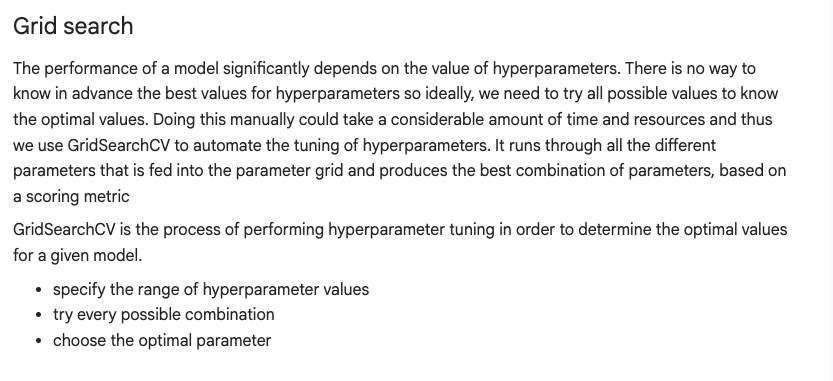

In [134]:
# list of alphas to tune
params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1,
 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100, 500, 1000 ]}

ridge = Ridge()

In [135]:
folds = 5

In [136]:
model_cv = GridSearchCV(estimator = ridge,
                        param_grid = params,
                        scoring= 'neg_mean_absolute_error',
                        cv = folds,
                        return_train_score=True,
                        verbose = 1)

In [137]:
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3,
                                   0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
                                   4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50,
                                   100, 500, 1000]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

In [144]:
model_cv.best_estimator_

Ridge(alpha=10.0)

In [138]:
cv_results = pd.DataFrame(model_cv.cv_results_)

In [139]:
cv_results = cv_results[cv_results['param_alpha']<=200]
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.004165,0.001167,0.002790,0.000297,0.0001,{'alpha': 0.0001},-2854.116752,-1413.812300,-1531.761541,-3968.369904,...,-2466.863611,937.837752,26,-694.753230,-814.178930,-832.351826,-903.775793,-720.171139,-793.046184,76.452403
1,0.004083,0.001103,0.003321,0.001567,0.0010,{'alpha': 0.001},-2846.765330,-1412.112714,-1533.523778,-3944.973694,...,-2460.751844,929.782223,25,-695.179504,-813.808050,-831.764642,-903.295166,-719.845373,-792.778547,76.185169
2,0.003580,0.000124,0.002540,0.000114,0.0100,{'alpha': 0.01},-2784.176328,-1396.101814,-1548.469470,-3780.266249,...,-2415.039453,873.169878,24,-699.262955,-811.621551,-827.106090,-898.841647,-717.550342,-790.876517,73.714558
3,0.005424,0.002510,0.004884,0.002151,0.0500,{'alpha': 0.05},-2640.682659,-1355.068116,-1580.736324,-3300.686592,...,-2285.104051,719.477783,23,-713.345673,-812.877044,-817.962405,-886.516756,-711.346429,-788.409662,67.335524
4,0.007769,0.002872,0.004186,0.001140,0.1000,{'alpha': 0.1},-2563.275484,-1359.228650,-1589.294656,-2966.273419,...,-2198.282455,615.981941,22,-721.902772,-815.578758,-811.644501,-878.629933,-708.742470,-787.299687,63.532012


In [146]:
cv_results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_alpha', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='object')

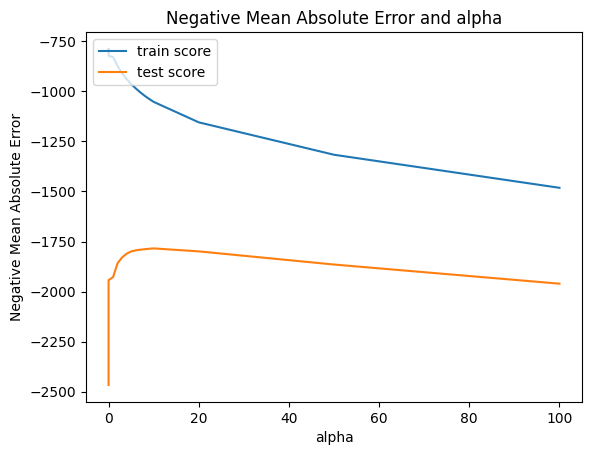

In [140]:
cv_results['param_alpha'] = cv_results['param_alpha'].astype('int32')

# plotting
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative Mean Absolute Error')
plt.title("Negative Mean Absolute Error and alpha")
plt.legend(['train score', 'test score'], loc='upper left')
plt.show()

In [147]:
alpha = 10

ridge = Ridge(alpha=alpha)

In [148]:
ridge.fit(X_train, y_train)

Ridge(alpha=10)

In [149]:
ridge.coef_

array([ 3.66439600e+02, -3.84733269e+01,  1.48385910e+03, -4.28871390e+02,
        1.32508938e+03,  1.53232524e+03, -1.32353686e+02, -3.43961178e+02,
       -3.85991151e+01,  1.00274451e+03,  4.08530524e+02,  3.06226713e+01,
       -3.86573031e+01,  2.80260386e+02,  2.25689703e+02,  1.15232435e+02,
        3.11172714e+01,  2.20999290e+02, -2.36604555e+02,  4.37146732e+02,
        8.11201095e+01, -4.17761691e+01, -6.36303725e+02, -3.89525755e+02,
       -2.67865922e+02, -2.25694801e+02,  2.17304590e+02,  1.01331104e+03,
       -7.99719800e+01, -2.11299602e+02,  3.80633116e+02,  5.02569921e+01,
       -2.68490049e+01,  1.31276809e+02, -5.38964122e+02, -5.61768987e+02,
       -2.24243763e+02,  3.30958997e+02, -3.41292337e+02,  1.31276809e+02,
        9.03941997e+01, -1.92932138e+02,  2.36604555e+02, -3.32698957e-28,
       -6.35149689e+01, -1.25417650e+02, -3.32698957e-28,  3.66335476e+02,
        1.54082286e+03,  1.04052995e+03, -1.83880719e+02, -4.32144537e+02,
       -3.65503794e+02, -

In [150]:
lasso = Lasso()

In [151]:
# cross validation
model_cv = GridSearchCV(estimator = lasso,
                        param_grid = params,
                        scoring= 'neg_mean_absolute_error',
                        cv = folds,
                        return_train_score=True,
                        verbose = 1)

model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3,
                                   0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
                                   4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50,
                                   100, 500, 1000]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

In [152]:
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.013824,0.002699,0.002718,0.000501,0.0001,{'alpha': 0.0001},-2324.752863,-1442.052401,-1582.911324,-3365.795489,...,-2209.514582,685.115001,15,-707.533143,-813.096166,-825.366072,-900.619438,-714.974164,-792.317797,72.696148
1,0.011513,0.001596,0.002470,0.000911,0.0010,{'alpha': 0.001},-2325.597811,-1441.914232,-1582.918610,-3365.543227,...,-2209.575240,685.082344,16,-707.541145,-813.094508,-825.357146,-900.608340,-714.974339,-792.315096,72.690031
2,0.019930,0.003495,0.003883,0.000761,0.0100,{'alpha': 0.01},-2334.050379,-1440.536627,-1582.991423,-3363.022314,...,-2210.185916,684.768785,17,-707.632117,-813.079516,-825.273418,-900.497476,-714.975747,-792.291655,72.627018
3,0.017683,0.000827,0.003409,0.000182,0.0500,{'alpha': 0.05},-2371.746047,-1434.479193,-1583.311429,-3351.844342,...,-2213.000651,683.667517,19,-708.062390,-813.098957,-825.058880,-900.011123,-715.024017,-792.251073,72.353255
4,0.017743,0.000738,0.003449,0.000097,0.1000,{'alpha': 0.1},-2419.028230,-1426.999122,-1583.704217,-3337.915603,...,-2216.697355,682.964265,20,-708.611287,-813.186719,-824.854499,-899.429607,-715.099045,-792.236231,72.023011


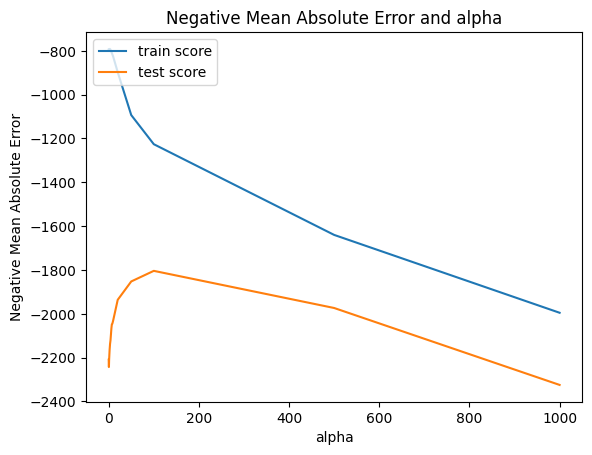

In [153]:
# plotting mean test and train scoes with alpha
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# plotting
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative Mean Absolute Error')

plt.title("Negative Mean Absolute Error and alpha")
plt.legend(['train score', 'test score'], loc='upper left')
plt.show()

In [154]:
model_cv.best_estimator_

Lasso(alpha=100)

In [155]:
alpha =100

lasso = Lasso(alpha=alpha)

lasso.fit(X_train, y_train)

Lasso(alpha=100)

In [156]:
lasso.coef_

array([   0.        ,   -0.        , 1747.1052243 ,  -82.23183774,
       1780.64173078,  788.28807799,   -0.        ,   -0.        ,
          0.        , 1017.48820119,   84.89633333,    0.        ,
         -0.        ,    0.        ,   -0.        ,   -0.        ,
          0.        ,  246.519852  ,  -73.38572878,  120.56790634,
          0.        ,    0.        , -187.60748943,    0.        ,
        -96.25412649, -134.39227325,  294.27227486, 1218.02281069,
          0.        ,   -0.        ,    0.        ,   -0.        ,
         -0.        ,    0.        ,   -0.        , -202.47407284,
         -0.        ,  197.70712322,   -0.        ,    0.        ,
         -0.        ,   -0.        ,   58.81424436,   -0.        ,
          0.        ,   -0.        ,   -0.        ,  186.35685239,
       1805.30123983, 1210.72936345,    0.        ,   -0.        ,
         -0.        ,   78.54297249,  796.29612837,    0.        ,
         -0.        , -397.80411254,  -58.198149  , -377.78256

In [157]:
## 10:25 pm

In [158]:
import numpy as np
import matplotlib.pyplot as plt

In [159]:
!gdown 1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m

Downloading...
From: https://drive.google.com/uc?id=1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m
To: /content/churn_logistic.csv
100% 494k/494k [00:00<00:00, 1.27MB/s]


In [160]:
import pandas as pd
churn = pd.read_csv("churn_logistic.csv")
churn.head()

,Account Length,VMail Message,Day Mins,Eve Mins,Night Mins,Intl Mins,CustServ Calls,Intl Plan,VMail Plan,Day Calls,...,Eve Calls,Eve Charge,Night Calls,Night Charge,Intl Calls,Intl Charge,State,Area Code,Phone,Churn
0,128,25,265.1,197.4,244.7,10.0,1,0,1,110,...,99,16.78,91,11.01,3,2.70,KS,415,382-4657,0
1,107,26,161.6,195.5,254.4,13.7,1,0,1,123,...,103,16.62,103,11.45,3,3.70,OH,415,371-7191,0
2,137,0,243.4,121.2,162.6,12.2,0,0,0,114,...,110,10.30,104,7.32,5,3.29,NJ,415,358-1921,0
3,84,0,299.4,61.9,196.9,6.6,2,1,0,71,...,88,5.26,89,8.86,7,1.78,OH,408,375-9999,0
4,75,0,166.7,148.3,186.9,10.1,3,1,0,113,...,122,12.61,121,8.41,3,2.73,OK,415,330-6626,0


In [162]:
churn['Churn'].value_counts()

,count
Churn,
0,2850
1,2850


In [163]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [164]:
def sigmoid(x):
    return 1/(1+np.e**-x)

In [165]:
x = np.linspace(-10, 10, 20)
x

array([-10.        ,  -8.94736842,  -7.89473684,  -6.84210526,
        -5.78947368,  -4.73684211,  -3.68421053,  -2.63157895,
        -1.57894737,  -0.52631579,   0.52631579,   1.57894737,
         2.63157895,   3.68421053,   4.73684211,   5.78947368,
         6.84210526,   7.89473684,   8.94736842,  10.        ])

In [166]:
z = sigmoid(x)
z

array([4.53978687e-05, 1.30062105e-04, 3.72561113e-04, 1.06671383e-03,
       3.05025951e-03, 8.69010558e-03, 2.45015898e-02, 6.71334989e-02,
       1.70944612e-01, 3.71376581e-01, 6.28623419e-01, 8.29055388e-01,
       9.32866501e-01, 9.75498410e-01, 9.91309894e-01, 9.96949740e-01,
       9.98933286e-01, 9.99627439e-01, 9.99869938e-01, 9.99954602e-01])

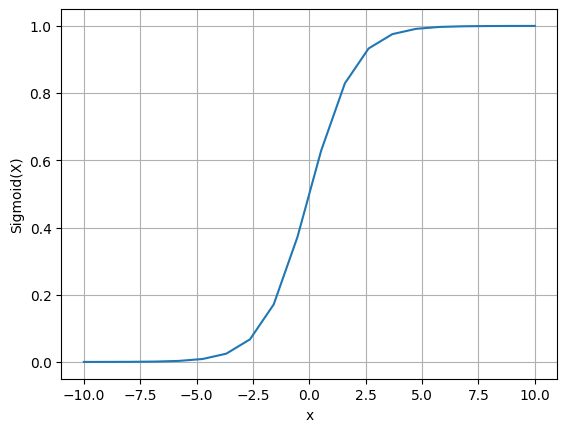

In [167]:
plt.plot(x, z)
plt.xlabel("x")
plt.ylabel("Sigmoid(X)")
plt.grid()
plt.show()

In [170]:
sigmoid(-100)

3.7200759760208555e-44